In [23]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [24]:
file_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"

In [25]:
df_ttest_alldrugs = pd.read_csv(f'{file_path}\drugs_dysregulation_summary_Ttest.csv',index_col=0)
df_ttest_alldrugs2 = df_ttest_alldrugs.copy()

In [26]:
file_path2= r"E:\project8  Robotics and AI enable automation in modern proteomics\files"
df_filter = pd.read_csv(f'{file_path2}\drug_names_replaced_filtered_raw_clean.csv', index_col = 0)

In [31]:
import mygene

mg = mygene.MyGeneInfo()

uniprot_ids = [item.split("cRAP-")[-1] for item in df_filter.index]

res2 = mg.querymany(
    uniprot_ids,
    scopes='uniprot',
    fields='symbol',
    species='human'
)

df_map = pd.DataFrame(res2)

# 3) 清洗：没找到 / 没有 symbol 的统一填 "No"
if "symbol" not in df_map.columns:
    df_map["symbol"] = None

df_map["symbol"] = df_map["symbol"].where(df_map["symbol"].notna(), other="No")
if "notfound" in df_map.columns:
    df_map.loc[df_map["notfound"] == True, "symbol"] = "No"

# 4) 保证一对一：同一个 query 如果出现多条，优先保留有 symbol 的那条
df_map["_is_no_"] = (df_map["symbol"] == "No").astype(int)
df_map = (
    df_map.sort_values(["query", "_is_no_"])
          .drop_duplicates(subset=["query"], keep="first")
          .drop(columns=["_is_no_"])
)

# 5) 建立映射 dict：query(uniprot) -> symbol(gene)
gene_map_dict = dict(zip(df_map["query"].astype(str), df_map["symbol"].astype(str)))

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
32 input query terms found dup hits:	[('B7ZAQ6', 2), ('P02489', 2), ('P0C0L4', 2), ('P0C0L5', 2), ('P0C0S8', 5), ('P0DMM9', 2), ('P0DMV8'
24 input query terms found no hit:	['A6NKF1', 'A8CG34', 'A8MWD9', 'C4AMC7', 'P01893', 'P51784', 'P57078', 'Q13670', 'Q58FF6', 'Q58FF8',


In [32]:
# 可选：看看映射表
print(df_map[["query", "symbol"]].head())

        query   symbol
0  A0A096LP01   SMIM26
1  A0A1W2PQ72  MSANTD7
2  A0A6Q8PH20     CAST
3  A0A804HLA8    GNG5B
4  A0AAG2UWQ9     NKRF


In [33]:
# 6) 给“另外一个 dataframe”加 gene 列
#    - 假设 df_other.index 也是 uniprot 或含 cRAP- 前缀
uniprot_other = [str(item).split("cRAP-")[-1] for item in df_ttest_alldrugs2.protein]
df_ttest_alldrugs2["gene"] = [gene_map_dict.get(uid, "No") for uid in uniprot_other]

df_ttest_alldrugs2

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj,gene
0,A0A096LP01,6-Mercaptopurine,-2.113386,0.076654,19.442643,19.655949,-0.213306,0.182348,SMIM26
1,A0A1W2PQ72,6-Mercaptopurine,0.388856,0.707633,13.956303,13.840781,0.115522,0.820512,MSANTD7
2,A0A6Q8PH20,6-Mercaptopurine,5.473972,0.000012,24.329154,24.179239,0.149915,0.000245,CAST
3,A0A804HLA8,6-Mercaptopurine,-1.632129,0.152713,15.289839,16.555034,-1.265195,0.298380,GNG5B
4,A0AAG2UWQ9,6-Mercaptopurine,-1.168956,0.259329,22.127657,22.167910,-0.040252,0.429875,NKRF
...,...,...,...,...,...,...,...,...,...
1048570,Q96NA2,Pergolide (mesylate),1.826891,0.084855,18.743508,18.541826,0.201682,0.196286,RILP
1048571,Q96NB1,Pergolide (mesylate),2.207872,0.047641,16.249791,15.928274,0.321517,0.128779,CEP20
1048572,Q96NB2,Pergolide (mesylate),-0.618561,0.558679,22.808630,22.839755,-0.031125,0.709873,SFXN2
1048573,Q96NB3,Pergolide (mesylate),2.380222,0.029191,22.266469,22.109358,0.157112,0.089650,ZNF830


# plot dysregulation bar plot

In [3]:
drug_func = pd.read_csv(r"E:\project8  Robotics and AI enable automation in modern proteomics\files\drugs.csv") 

In [48]:
# Filter significant dysregulation (FDR < 0.05)
sig = df_ttest_alldrugs2[df_ttest_alldrugs2["p_value_adj"] < 0.05].copy()

# Compute up- and down-regulated counts per drug
summary = sig.groupby("drug").apply(
    lambda g: pd.Series({
        "up": (g["log2FC"] > 0.5).sum(),
        "down": (g["log2FC"] < -0.5).sum(),
        "total": len(g)
    })
).reset_index()

print(summary.head())
print(summary.shape)

                             drug   up  down  total
0                6-Mercaptopurine  275   311   3082
1               ATP (dimagnesium)  105    55   1988
2  Abemaciclib (methanesulfonate)  749  1424   4293
3      Acetophenazine (dimaleate)  358    38   2898
4      Adiphenine (hydrochloride)   61    32   1588
(170, 4)


In [4]:
def first_item(x):
    """Return only the first item if multiple values are separated by ';'."""
    if not isinstance(x, str):
        return "Unknown"
    return x.split(";")[0].strip()

In [5]:
drug_func["Target_clean"] = drug_func["Target"].apply(first_item)

map_dict = dict(zip(drug_func["ProductName"], drug_func["Target_clean"]))

In [51]:
summary["target"] = summary["drug"].map(map_dict)
summary["target"] = summary["target"].fillna("Others")

In [52]:
keep = [
    "Autophagy",
    "Histamine Receptor",
    "Endogenous Metabolite",
    "Glucocorticoid Receptor",
    "Dopamine Receptor",
    "iGluR",
    "EGFR",
    "nAChR",
    "Cytochrome P450",
    "5-HT Receptor",                
    "Na+/K+ ATPase",
    "Others"
]

summary.loc[~summary["target"].isin(keep), "target"] = "Others"

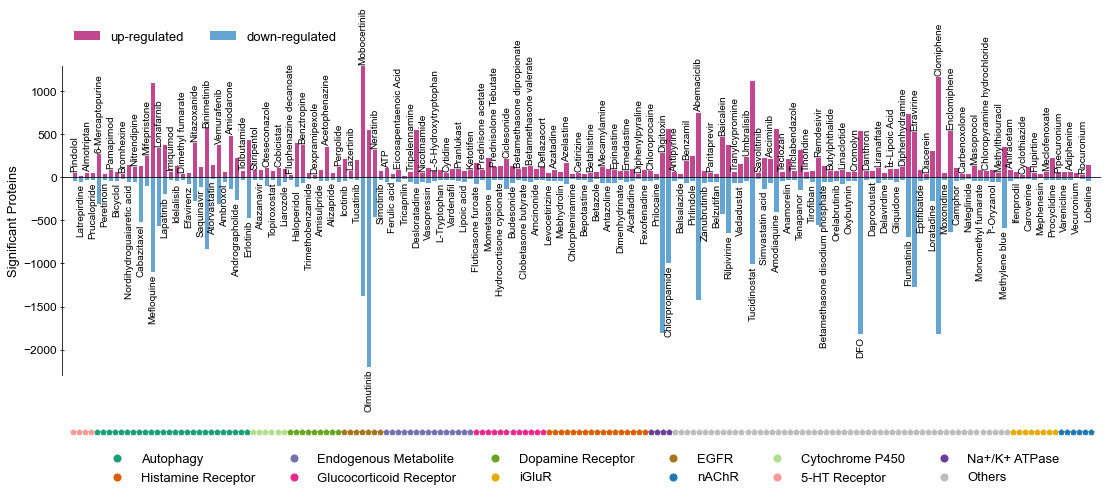

In [53]:

plt.rcParams['font.family'] = 'Arial'

df = summary.copy()
df["drug"] = df["drug"].astype(str).str.replace(r"\s*\([^)]*\)\s*$", "", regex=True)
df = df.sort_values("target").reset_index(drop=True)
# Define the dictionary mapping categories to colors
category_colors = {
    "Autophagy": "#1b9e77",              # teal-green
    "Histamine Receptor": "#d95f02",     # orange
    "Endogenous Metabolite": "#7570b3",  # purple
    "Glucocorticoid Receptor": "#e7298a",# magenta
    "Dopamine Receptor": "#66a61e",      # green
    "iGluR": "#e6ab02",                  # mustard
    "EGFR": "#a6761d",                   # brown
    "nAChR": "#1f78b4",                  # blue
    "Cytochrome P450": "#b2df8a",        # light green
    "5-HT Receptor": "#fb9a99",          # pink
    "Na+/K+ ATPase": "#6a3d9a",          # dark purple
    "Others": "#bdbdbd"                  # gray
}

# Create subplots - 2 subplots in 1 column (vertical layout)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16,7), gridspec_kw={'height_ratios': [14, 1]})
plt.rcParams['font.family'] = 'Arial'

# Reduce space between subplots, allow overlap
plt.subplots_adjust(hspace= - 0.1)

# Plot for Proteome and Metabolome on the first subplot (ax1)
ax1.bar(df.index, df['up'], width=0.8, align='center', label='up-regulated', color='#C3478F')
ax1.bar(df.index, -df['down'], width=0.8, align='center', label='down-regulated', color='#64A5D3')

# Add rotated text labels for 'sig_pro_bhnum' (positive values) in ax1
for i in range(0, len(df), 2):
    ax1.text(i, df['up'].iloc[i] + 20, df.drug[i], ha='center', va='bottom', rotation=90, fontsize=10)
for i in range(1, len(df), 2):
    ax1.text(i, -df['down'].iloc[i] - 20, df.drug[i], ha='center', va='top', rotation=90, fontsize=10)

colorn = "black"
# Customize ax1 (bar plot)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_color(colorn)  
ax1.axhline(0, color=colorn, linewidth=0.8)
ax1.set_ylim(-2300, 1300)
# ax1.set_yticks(range(-250, 171, 100))
ax1.set_ylabel('Significant Proteins', fontsize=13, color=colorn)
ax1.set_xticks([])  # Remove x-ticks for the bar plot
ax1.legend(fontsize=13, loc='upper left',frameon=False,ncol=2,bbox_to_anchor=(0, 1.15))
ax1.tick_params(axis='y', labelsize=12, labelcolor=colorn, direction='inout')
ax1.margins(x=0.01) 

# Scatter plot for category colors on the second subplot (ax2)
for i in range(len(df)):
    category = df['target'].iloc[i]
    circle_color = category_colors.get(category, 'black')  # Default to 'black' if not found
    ax2.scatter(i, 0, color=circle_color, marker = 'p',s=30, zorder=5)

# Customize ax2 (scatter plot)
ax2.set_ylim(-1, 1)  # Keep the scatter plot tight in height
ax2.set_yticks([])  # Remove y-ticks
ax2.set_xticks([])  # Remove x-ticks
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.margins(x=0.01) 
# Manually adjust the position of the legend for ax2
scatter_proxies = [ax2.scatter([], [], color=color, s=50) for color in category_colors.values()]
ax2.legend(scatter_proxies, category_colors.keys(), fontsize=13, loc='upper center', ncol=6, frameon=False,
           bbox_to_anchor=(0.5, 0.1))
# Adjust layout
plt.tight_layout()
plt.savefig(f'{figure_path}/barplot_drugs_dys.svg', dpi=600, bbox_inches='tight')
plt.show()

# Scatter plot of proteome response

In [54]:
# Compute per-protein up/down counts across all drugs
protein_summary = sig.groupby("protein").apply(
    lambda g: pd.Series({
        "up": (g["log2FC"] > 0.5).sum(),
        "down": (g["log2FC"] < -0.5).sum(),
        "total": len(g)
    })
).reset_index()

print(protein_summary.head())
print(protein_summary.shape)

      protein  up  down  total
0  A0A096LP01   0    21     44
1  A0A1W2PQ72   4     5     12
2  A0A6Q8PH20   1     0     31
3  A0A804HLA8  14     1     15
4  A0AAG2UWQ9   0     0     70
(8140, 4)


In [56]:
df_map

,query,_id,_score,symbol,notfound
0,A0A096LP01,388789,20.059680,SMIM26,NaN
1,A0A1W2PQ72,100421372,20.059680,MSANTD7,NaN
2,A0A6Q8PH20,831,28.468374,CAST,NaN
3,A0A804HLA8,347687,20.059673,GNG5B,NaN
4,A0AAG2UWQ9,55922,28.468246,NKRF,NaN
...,...,...,...,...,...
8189,Q9Y6X4,26049,20.059673,FAM169A,NaN
8190,Q9Y6X8,22882,20.059673,ZHX2,NaN
8191,Q9Y6X9,22880,20.059680,MORC2,NaN
8192,Q9Y6Y0,10625,20.059673,IVNS1ABP,NaN


In [57]:
protein_summary

,protein,up,down,total
0,A0A096LP01,0,21,44
1,A0A1W2PQ72,4,5,12
2,A0A6Q8PH20,1,0,31
3,A0A804HLA8,14,1,15
4,A0AAG2UWQ9,0,0,70
...,...,...,...,...
8135,cRAP-O77727,6,0,6
8136,cRAP-P00761,16,14,125
8137,cRAP-P02769,7,57,83
8138,cRAP-P12763,13,66,101


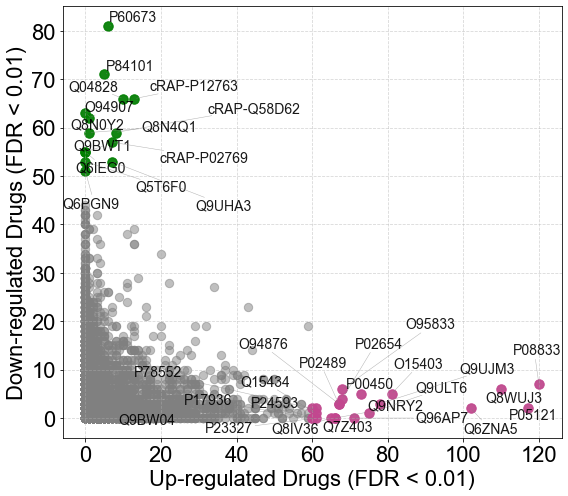

In [55]:
from adjustText import adjust_text
import re

up_thr_pro = 60
down_thr_pro = 50

# Define masks
mask_up = protein_summary["up"] >= up_thr_pro
mask_down = protein_summary["down"] >= down_thr_pro
mask_sig = mask_up | mask_down  # any significant point

plt.figure(figsize=(8, 7))

# 1. Plot all background drugs (gray)
plt.scatter(
    protein_summary["up"],
    protein_summary["down"],
    alpha=0.5,
    s=70,
    color="gray"
)

# 2. Highlight significant UP points (red)
plt.scatter(
    protein_summary.loc[mask_up, "up"],
    protein_summary.loc[mask_up, "down"],
    alpha=0.9,
    s=90,
    color="#C3478F",
    label=f"Up >= {up_thr_pro}"
)

# 3. Highlight significant DOWN points (blue)
plt.scatter(
    protein_summary.loc[mask_down, "up"],
    protein_summary.loc[mask_down, "down"],
    alpha=0.9,
    s=90,
    color="green",
    label=f"Down >= {down_thr_pro}"
)

# Optional: label only significant points
texts = []
for _, row in protein_summary[mask_sig].iterrows():
    texts.append(
        plt.text(
            row["up"],
            row["down"],
            row["protein"],
            fontsize=14,
            alpha=0.9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6)
)

# Axis labels & aesthetics
plt.xlabel("Up-regulated Drugs (FDR < 0.01)", fontsize=22)
plt.ylabel("Down-regulated Drugs (FDR < 0.01)", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend(fontsize=16)
plt.tight_layout()

# plt.savefig(f"{figure_path}/scatter of proteome response rate.svg", dpi=600)
plt.show()

# volcano plot of selected drug

In [72]:
# =========================
# 1. Load your data
# =========================
# df_stats = df_ttest_alldrugs2.copy()  # contains drug, protein, p_value, log2FC?
df_stats = df_ttest_all.copy()  # contains drug, protein, p_value, log2FC?
# df_expr  = df.copy()     # contains expression values (if needed)

# Inspect column names
print(df_stats.columns)

Index(['protein', 'drug', 't_stat', 'p_value', 'mean_drug', 'mean_DMSO',
       'log2FC', 'p_value_adj', 'query', 'gene_symbol'],
      dtype='object')


In [85]:
import re
from adjustText import adjust_text

def plot_volcano(
        df,
        drug_name,
        fc_col="log2FC",
        p_col="p_value_adj",   # adjusted p-value
        protein_col="protein",
        fc_thresh=1.0,
        p_thresh=0.05,
        figsize=(6,5)
    ):
    
    # Filter selected drug
    d = df[df["drug"] == drug_name].copy()
    
    # Compute negative log10 (avoid -inf)
    d["neglog10p"] = -np.log10(d[p_col].replace(0, np.nan))

    # Significance mask
    d["sig_up"] = (d[p_col] < p_thresh) & (d[fc_col] >  fc_thresh)
    d["sig_down"] = (d[p_col] < p_thresh) & (d[fc_col] < -fc_thresh)

    # Base plot: all non-significant points (gray)
    plt.figure(figsize=figsize)
    nonsig = d[~(d["sig_up"] | d["sig_down"])]
    plt.scatter(nonsig[fc_col], nonsig["neglog10p"], color="gray", alpha=0.5)

    # Upregulated proteins (red)
    up = d[d["sig_up"]]
    plt.scatter(up[fc_col], up["neglog10p"], color="red", alpha=0.9, label="Up")

    # Downregulated proteins (green)
    down = d[d["sig_down"]]
    plt.scatter(down[fc_col], down["neglog10p"], color="green", alpha=0.9, label="Down")

    # Text labels (non overlapping)
    texts = []
    for _, row in pd.concat([up, down]).iterrows():
        texts.append(
            plt.text(row[fc_col], row["neglog10p"], row[protein_col], fontsize=14)
        )
    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.5))

    # Threshold lines
    plt.axvline(fc_thresh, color="black", ls="--")
    plt.axvline(-fc_thresh, color="black", ls="--")
    plt.axhline(-np.log10(p_thresh), color="black", ls="--")

    plt.xlabel("Log2 Fold Change", fontsize=20)
    plt.ylabel("-Log10 FDR (adjusted p-value)", fontsize=20)
    plt.xticks(fontsize=19)
    plt.yticks(fontsize=19)
    drug_name2 = re.sub(r'\s*\(.*?\)', '', drug_name)
    plt.title(f"{drug_name2}",fontsize=22)

    plt.legend(fontsize=16)
    plt.tight_layout()

    plt.savefig(f'{figure_path}/Volcano Plot – {drug_name2}.svg', dpi=300)
    plt.show()

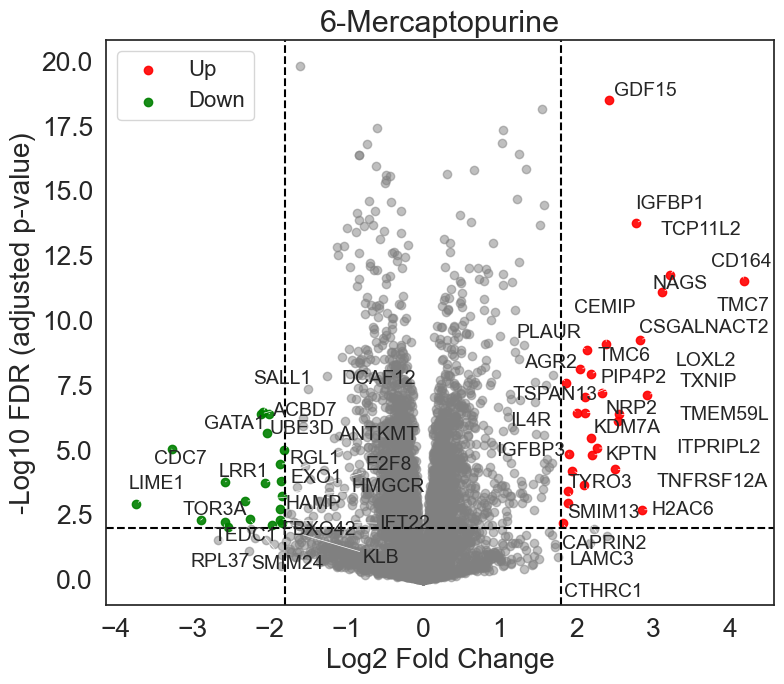

In [86]:
# =========================
# 3. Run for any drug
# =========================
plot_volcano(df_stats, drug_name="6-Mercaptopurine",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="gene_symbol",
             fc_thresh=1.8,
             p_thresh=0.01,
             figsize=(8,7)
            )

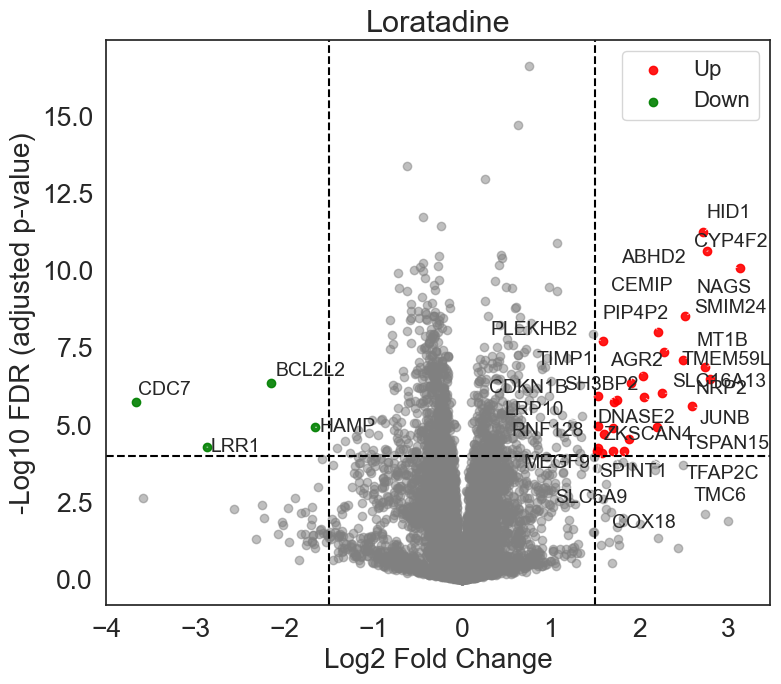

In [93]:
plot_volcano(df_stats, drug_name="Loratadine",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="gene_symbol",
             fc_thresh=1.5,
             p_thresh=0.0001,
             figsize=(8,7)
            )

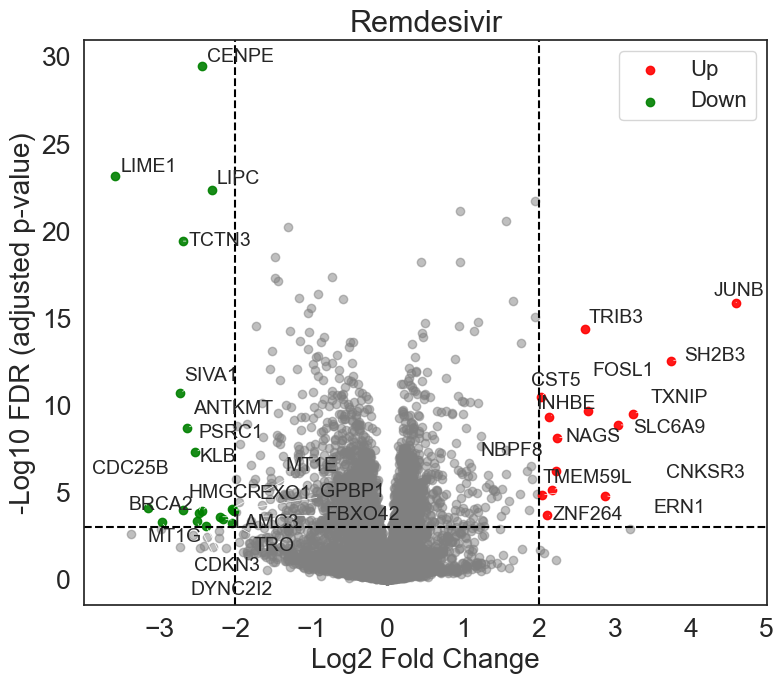

In [88]:
plot_volcano(df_stats, drug_name="Remdesivir",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="gene_symbol",
             fc_thresh=2,
             p_thresh=0.001,
             figsize=(8,7)
            )

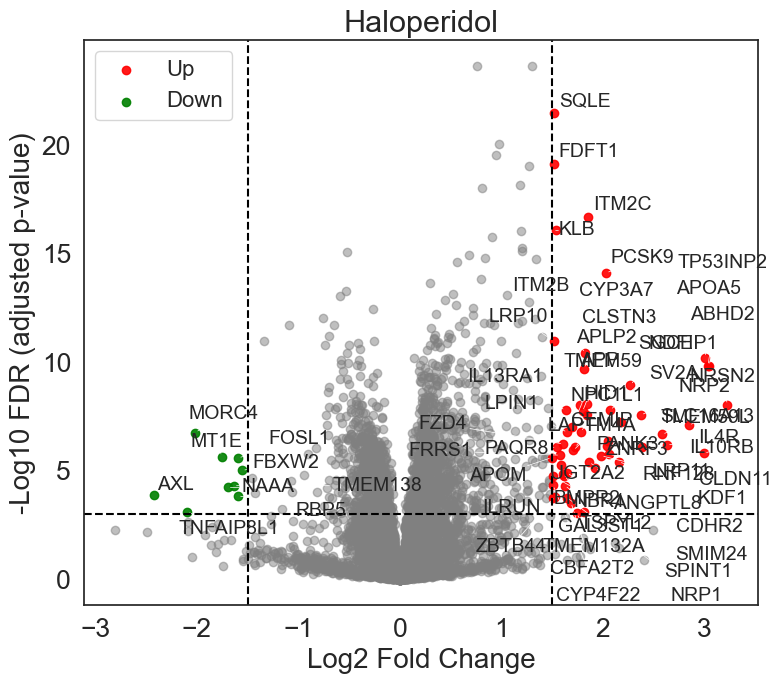

In [89]:
plot_volcano(df_stats, drug_name="Haloperidol",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="gene_symbol",
             fc_thresh=1.5,
             p_thresh=0.001,
             figsize=(8,7)
            )

In [90]:
df_stats

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj,query,gene_symbol
0,A0A096LP01,6-Mercaptopurine,-2.113386,7.665441e-02,19.442643,19.655949,-0.213306,0.182348,A0A096LP01,SMIM26
1,A0A1W2PQ72,6-Mercaptopurine,0.388856,7.076332e-01,13.956303,13.840781,0.115522,0.820512,A0A1W2PQ72,MSANTD7
2,A0A6Q8PH20,6-Mercaptopurine,5.473972,1.167830e-05,24.329154,24.179239,0.149915,0.000245,A0A6Q8PH20,CAST
3,A0A804HLA8,6-Mercaptopurine,-1.632129,1.527133e-01,15.289839,16.555034,-1.265195,0.298380,A0A804HLA8,GNG5B
4,A0AAG2UWQ9,6-Mercaptopurine,-1.168956,2.593294e-01,22.127657,22.167910,-0.040252,0.429875,A0AAG2UWQ9,NKRF
...,...,...,...,...,...,...,...,...,...,...
1384815,cRAP-O77727,DFO,3.002222,4.628480e-03,24.828922,24.140402,0.688520,0.022427,NaN,NaN
1384816,cRAP-P00761,DFO,5.864143,5.434324e-07,32.340354,31.608482,0.731872,0.000024,NaN,NaN
1384817,cRAP-P02769,DFO,-4.605658,4.137180e-05,27.403938,27.988360,-0.584423,0.000631,NaN,NaN
1384818,cRAP-P12763,DFO,0.225953,8.224648e-01,30.061601,30.039859,0.021742,0.896596,NaN,NaN


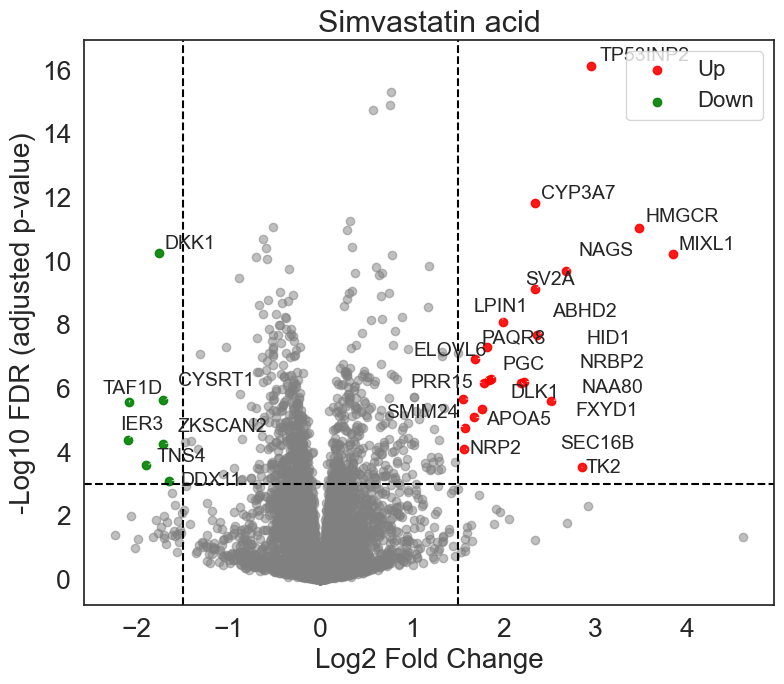

In [91]:
plot_volcano(df_stats, drug_name="Simvastatin acid (ammonium)",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="gene_symbol",
             fc_thresh=1.5,
             p_thresh=0.001,
             figsize=(8,7)
            )

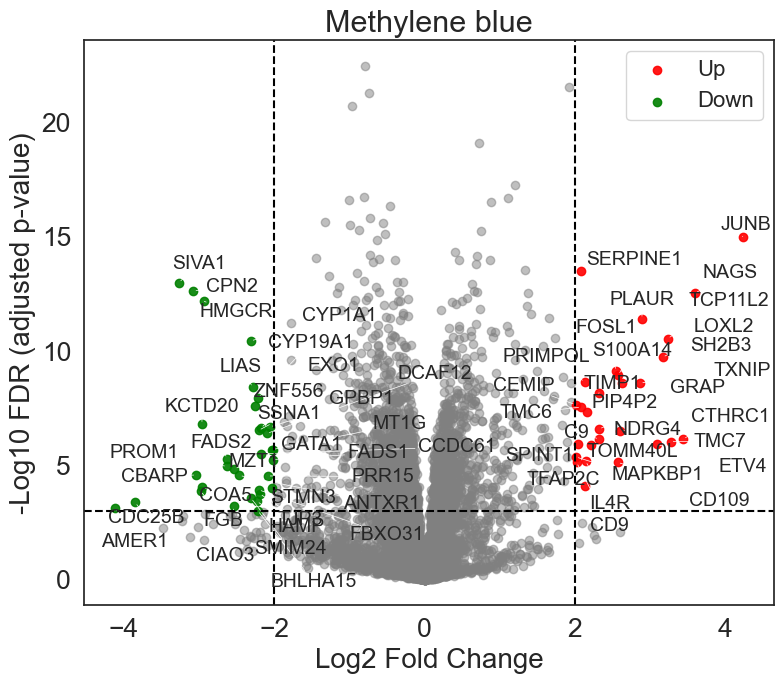

In [92]:
# =========================
# 3. Run for any drug
# =========================
plot_volcano(df_stats, drug_name="Methylene blue (trihydrate)",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="gene_symbol",
             fc_thresh=2,
             p_thresh=0.001,
             figsize=(8,7)
            )

# histogram of the dysregulation drugs and proteins

In [71]:
file_path_manual = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS"

df_ttest_all = pd.read_csv(f'{file_path_manual}/drugs_dysregulation_summary_Ttest_gene_added.csv', index_col = 0) 

In [7]:
df_ttest_all.columns

Index(['protein', 'drug', 't_stat', 'p_value', 'mean_drug', 'mean_DMSO',
       'log2FC', 'p_value_adj', 'query', 'gene_symbol'],
      dtype='object')

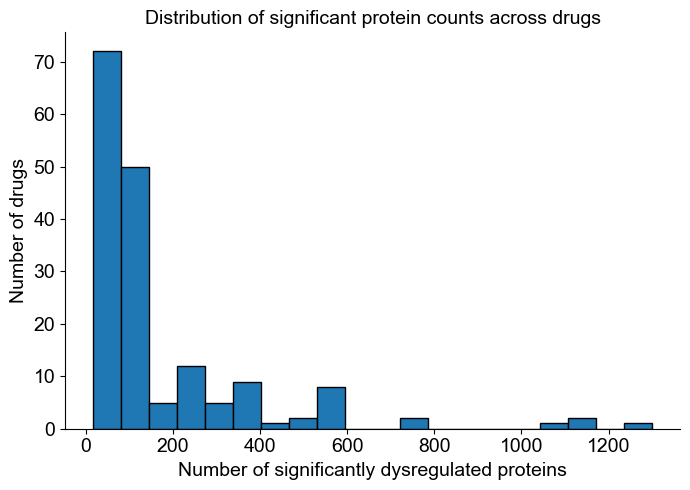

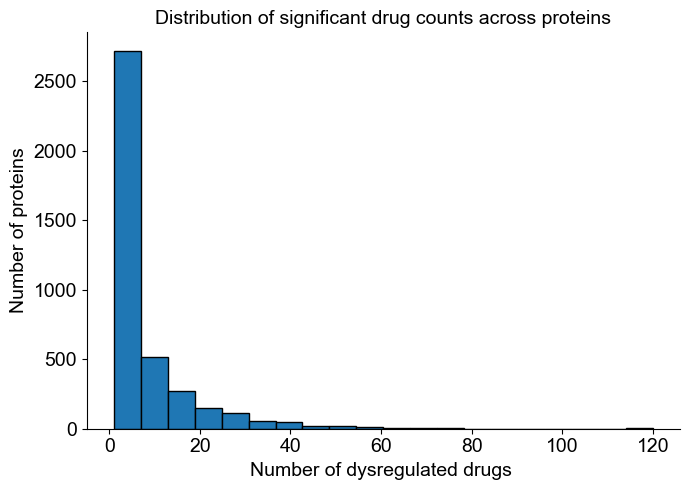

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. 筛选显著上调结果
# =========================
sig_df = df_ttest_all[
    (df_ttest_all["p_value_adj"] < 0.05) &
    (df_ttest_all["log2FC"].abs() > 0.5)
].copy()

# =========================
# 2. 统计每个 drug 的显著 protein 数量
# =========================
drug_counts = (
    sig_df.groupby("drug")["protein"]
    .nunique()
)

# =========================
# 3. 统计每个 protein 在多少个 drug 中显著上调
# =========================
protein_counts = (
    sig_df.groupby("protein")["drug"]
    .nunique()
)

# 如果你更想按 gene_symbol 统计，可以改成：
# protein_counts = sig_df.groupby("gene_symbol")["drug"].nunique()
plt.rcParams["font.family"] = "Arial"
# =========================
# 4. drug histogram
# 横轴 = 每个drug显著protein数量
# 纵轴 = 有多少个drug落在这个区间
# =========================
plt.figure(figsize=(7, 5))
plt.hist(drug_counts, bins=20, edgecolor="black")

plt.xlabel("Number of significantly dysregulated proteins", fontsize=14)
plt.ylabel("Number of drugs", fontsize=14)
plt.title("Distribution of significant protein counts across drugs", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

# =========================
# 5. protein histogram
# 横轴 = 每个protein在多少个drug中显著
# 纵轴 = 有多少个protein落在这个区间
# =========================
plt.figure(figsize=(7, 5))
plt.hist(protein_counts, bins=20, edgecolor="black")

plt.xlabel("Number of dysregulated drugs ", fontsize=14)
plt.ylabel("Number of proteins", fontsize=14)
plt.title("Distribution of significant drug counts across proteins", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

plt.show()

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 全局画图风格（Arial + 干净风格）
# =========================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.set(style="white")

# =========================
# 保存路径
# =========================
save_dir = r"E:\project8  Robotics and AI enable automation in modern proteomics\KOSMOS\figures"
os.makedirs(save_dir, exist_ok=True)

# =========================
# 1. 筛选显著上调
# =========================
sig_df = df_ttest_all[
    (df_ttest_all["p_value_adj"] < 0.05) &
    (df_ttest_all["log2FC"].abs() > 0.5)
].copy()

# =========================
# 2. 统计
# =========================
drug_counts = sig_df.groupby("drug")["protein"].nunique()
protein_counts = sig_df.groupby("protein")["drug"].nunique()

# =========================
# 3. Histogram（自动bins）
# =========================
plt.figure(figsize=(6.5, 5))
plt.hist(drug_counts, bins=20, edgecolor="black")

plt.xlabel("Significant proteins per drug", fontsize=14)
plt.ylabel("Number of drugs", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# 去掉上右边框（Nature风格）
sns.despine()

plt.tight_layout()

plt.savefig(os.path.join(save_dir, "drug_histogram.svg"))
plt.close()

# =========================
# 4. 手动分箱（推荐发文章）
# =========================
bins = [0, 100, 200, 300, 400, 500, 1000,2000,3000]

bin_counts = pd.cut(drug_counts, bins=bins).value_counts().sort_index()

plt.figure(figsize=(6.5, 5))
plt.bar(
    bin_counts.index.astype(str),
    bin_counts.values,
    edgecolor="black"
)

plt.xticks(rotation=30, ha="right")
plt.xlabel("Significant protein count per drug", fontsize=12)
plt.ylabel("Number of drugs", fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
sns.despine()

plt.tight_layout()

plt.savefig(os.path.join(save_dir, "drug_binned_barplot.svg"))
plt.close()

# =========================
# 5. protein histogram（可选）
# =========================
plt.figure(figsize=(6.5, 5))
plt.hist(protein_counts, bins=20, edgecolor="black")

plt.xlabel("Drugs per protein", fontsize=14)
plt.ylabel("Number of proteins", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
sns.despine()

plt.tight_layout()

plt.savefig(os.path.join(save_dir, "protein_histogram.svg"))
plt.close()